In [161]:
# for 시각화
import matplotlib.pyplot as plt   
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
# import sklearn
# print(sklearn.__version__)

print('얍💢')

얍💢


In [162]:

# 데이터
train_data_path = join('./data', 'train.csv')
sub_data_path = join('./data', 'test.csv')

## 1. 데이터 살펴보기
pandas의 read_csv 함수를 사용해 데이터를 읽어오고, 각 변수들이 나타내는 의미를 살펴보겠습니다.
1. ID : 집을 구분하는 번호
2. date : 집을 구매한 날짜
3. price : 타겟 변수인 집의 가격
4. bedrooms : 침실의 수
5. bathrooms : 침실당 화장실 개수
6. sqft_living : 주거 공간의 평방 피트
7. sqft_lot : 부지의 평방 피트
8. floors : 집의 층 수
9. waterfront : 집의 전방에 강이 흐르는지 유무 (a.k.a. 리버뷰)
10. view : 집이 얼마나 좋아 보이는지의 정도
11. condition : 집의 전반적인 상태
12. grade : King County grading 시스템 기준으로 매긴 집의 등급
13. sqft_above : 지하실을 제외한 평방 피트
14. sqft_basement : 지하실의 평방 피트
15. yr_built : 집을 지은 년도
16. yr_renovated : 집을 재건축한 년도
17. zipcode : 우편번호
18. lat : 위도
19. long : 경도
20. sqft_living15 : 2015년 기준 주거 공간의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음)
21. sqft_lot15 : 2015년 기준 부지의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음)

In [163]:

# 데이터 읽기
data = pd.read_csv(train_data_path)
sub = pd.read_csv(sub_data_path)
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))


train data dim : (15035, 21)
sub data dim : (6468, 20)


In [164]:

# 학습 데이터에서 라벨 제거하기
# y = data['price']
# 학습 데이터 라벨링 수정. price 로그로 감싸기
y = np.log1p(data['price'])  
del data['price']


In [165]:

# 학습 데이터와 테스트 데이터 합치기
train_len = len(data)
data = pd.concat((data, sub), axis=0)


In [166]:

# 합친 후 데이터 확인
print(len(data))
data.head()

21503


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


## 2. 간단한 전처리 
각 변수들에 대해 결측 유무를 확인하고, 분포를 확인해보면서 간단하게 전처리를 하겠습니다.
### 결측치 확인
먼저 데이터에 결측치가 있는지를 확인하겠습니다.<br>
missingno 라이브러리의 matrix 함수를 사용하면, 데이터의 결측 상태를 시각화를 통해 살펴볼 수 있습니다.

<Axes: >

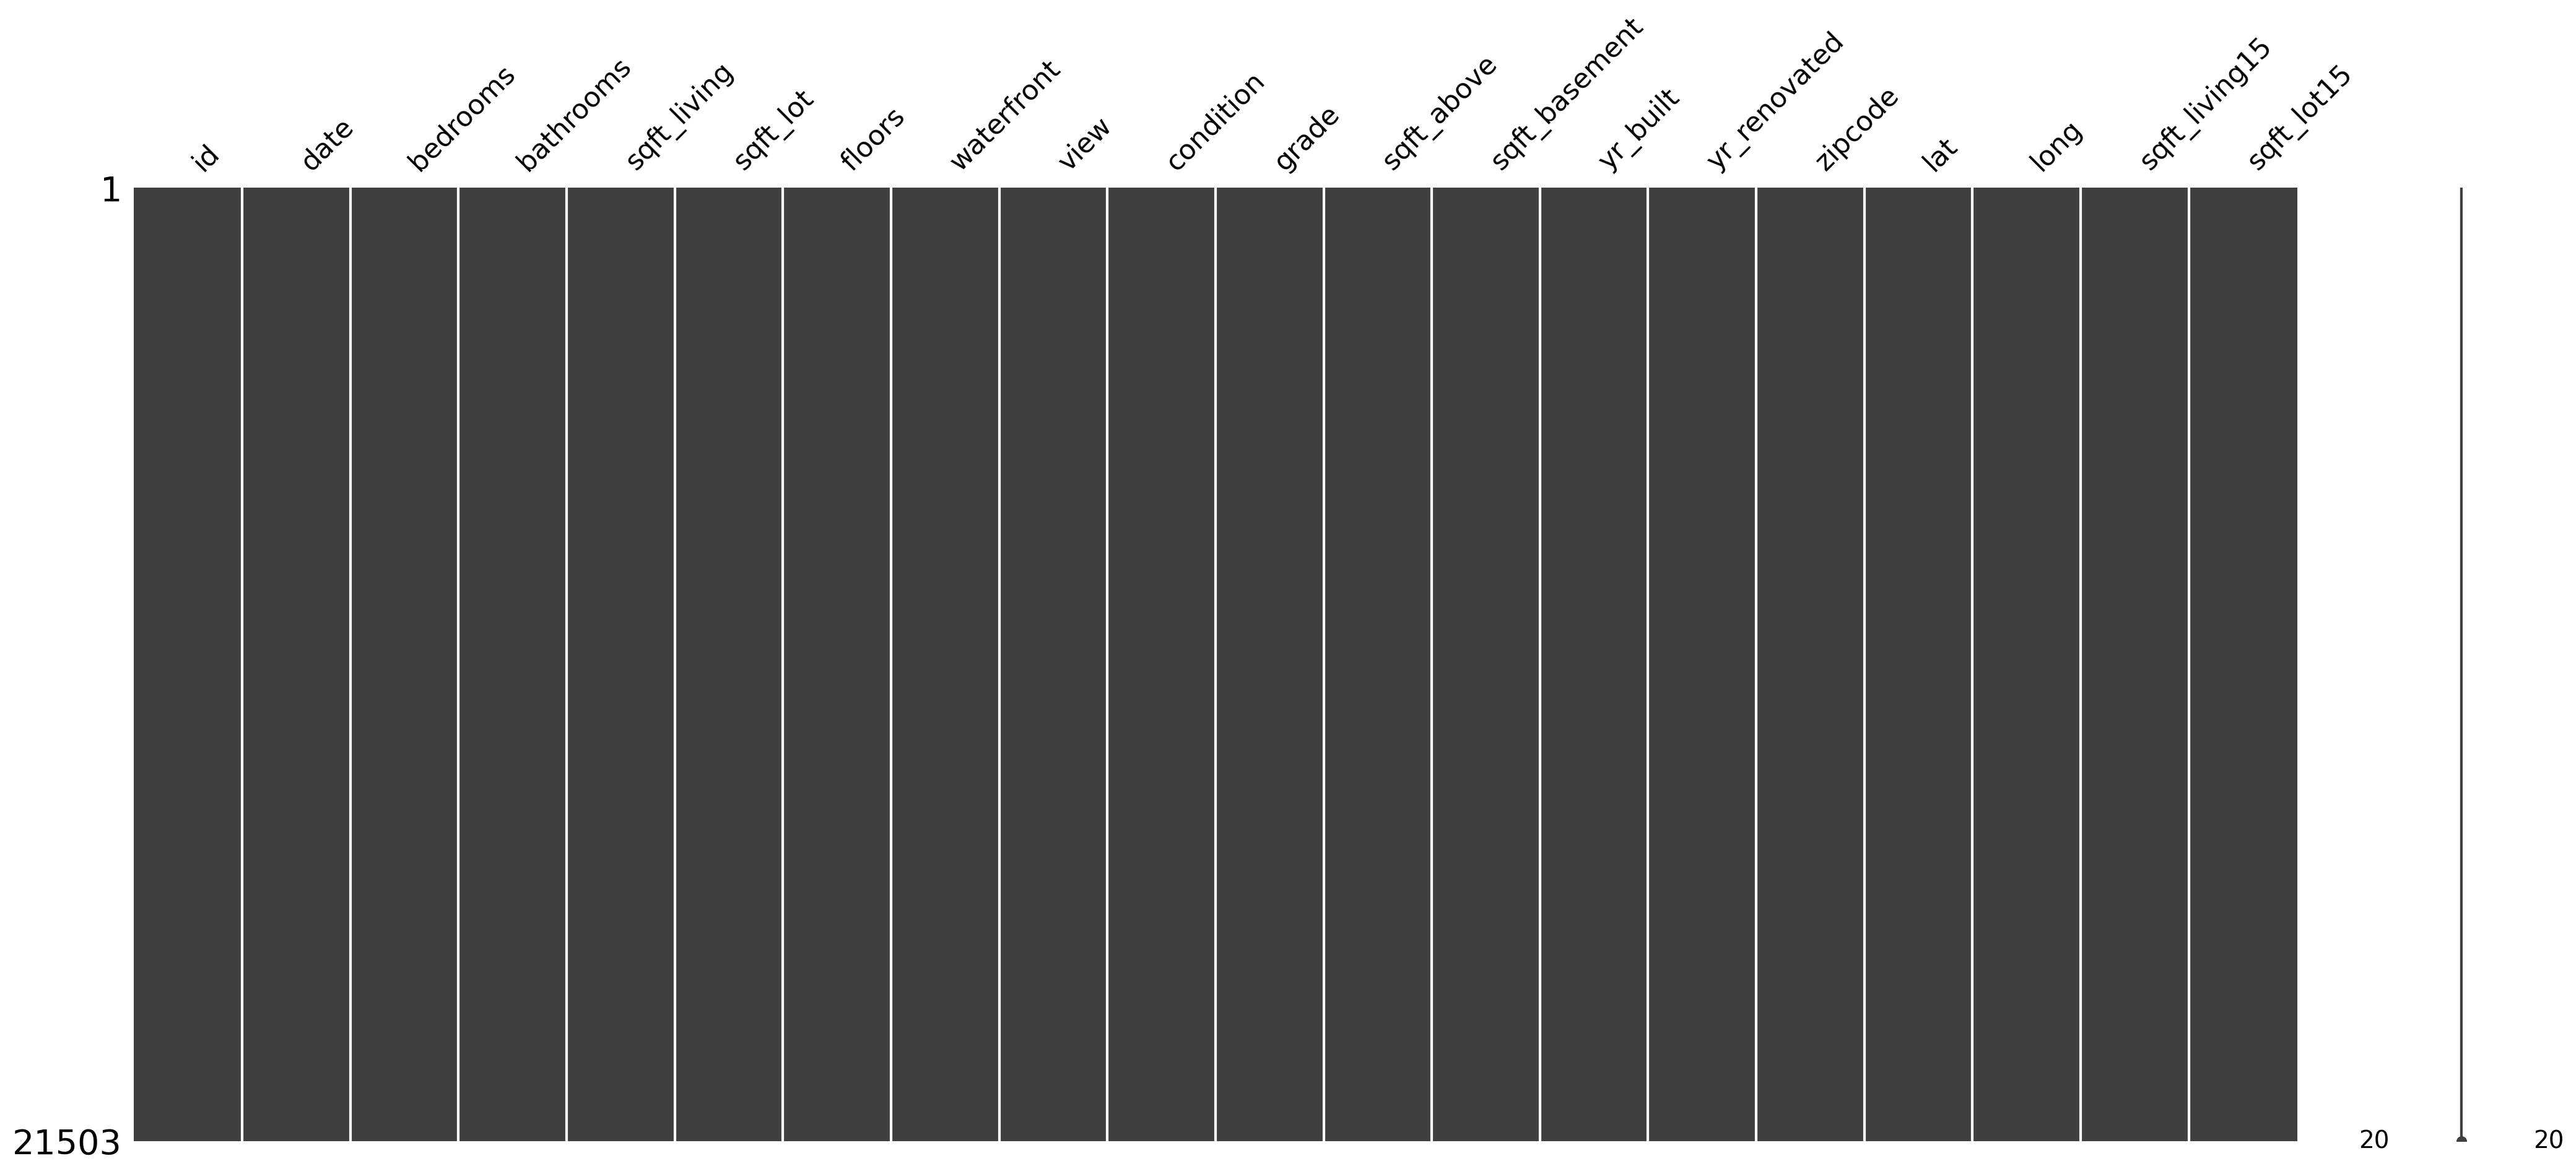

In [167]:
msno.matrix(data)

모든 변수에 결측치가 없는 것으로 보이지만, 혹시 모르니 확실하게 살펴보겠습니다.<br>

In [168]:
for c in data.columns:
    print('{} : {}'.format(c, len(data.loc[pd.isnull(data[c]), c].values)))

id : 0
date : 0
bedrooms : 0
bathrooms : 0
sqft_living : 0
sqft_lot : 0
floors : 0
waterfront : 0
view : 0
condition : 0
grade : 0
sqft_above : 0
sqft_basement : 0
yr_built : 0
yr_renovated : 0
zipcode : 0
lat : 0
long : 0
sqft_living15 : 0
sqft_lot15 : 0


### id, date 변수 정리
id 변수는 모델이 집값을 예측하는데 도움을 주지 않으므로 제거합니다.<br>
date 변수는 연월일시간으로 값을 가지고 있는데, 연월만 고려하는 범주형 변수로 만들겠습니다.

In [169]:
sub_id = data['id'][train_len:]
del data['id']
data['date'] = data['date'].apply(lambda x : str(x[:6])).astype(str)

# 추가
# 판매연도 정수변환 
data['year'] = data['date'].apply(lambda x: int(x[:4]))  
data['month'] = data['date'].apply(lambda x: int(str(x)[4:6]))

# 1. 집 나이 = (판매연도 - 완공연도)
data['house_age'] = data['year'] - data['yr_built']     

# 2. 재건축 후 경과 년수
# 재건축 무 : 왼공후 나이, 재건축 유 : 재건축시점부터 계산
data['age_since_renovation'] = data.apply(
    lambda x: x['house_age'] if x['yr_renovated'] == 0 else x['year'] - x['yr_renovated'], axis=1
)

# 위도와 경도 데이터만 추출
coords = data[['lat', 'long']]

# 30개의 구역으로 나누기 (n_clusters는 조절 가능)
kmeans = KMeans(n_clusters=30, random_state=2019)
data['cluster'] = kmeans.fit_predict(coords)

# 1. 학습 데이터 부분만 복사해서 가격(y) 정보 추가
temp_train = data.iloc[:train_len].copy()
temp_train['price'] = y.values # y는 이미 로그 변환된 상태

# 2. 클러스터(구역)별로 평균 가격 계산
cluster_mean = temp_train.groupby('cluster')['price'].mean()

# 3. cluster_price : 전체 데이터(data)의 구역 번호를 해당 평균 가격으로 변환하여 새 컬럼 생성
data['cluster_price'] = data['cluster'].map(cluster_mean)

# 4. zipcode_price : zipcode별 평균가격 (위치 정보 다른 각도)
temp_train = data.iloc[:train_len].copy()
temp_train['price'] = y.values

zipcode_mean = temp_train.groupby('zipcode')['price'].mean()
data['zipcode_price'] = data['zipcode'].map(zipcode_mean)

# 5. grade × sqft_living (XGBoost에서 둘 다 상위권)
data['grade_x_living'] = data['grade'] * data['sqft_living']

# 6. lat × long 
data['lat_x_long'] = data['lat'] * data['long']

# 7. 삭제 피처
del data['cluster']
del data['year']


In [170]:
data.head()

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,long,sqft_living15,sqft_lot15,month,house_age,age_since_renovation,cluster_price,zipcode_price,grade_x_living,lat_x_long
0,201410,3,1.00,1180,5650,1.0,0,0,3,7,...,-122.257,1340,5650,10,59,59,12.771992,12.560076,8260,-5808.576778
1,201502,2,1.00,770,10000,1.0,0,0,3,6,...,-122.233,2720,8062,2,82,82,13.078015,12.987830,4620,-5835.146731
2,201502,3,2.00,1680,8080,1.0,0,0,3,8,...,-122.045,1800,7503,2,28,28,13.410550,13.393930,13440,-5811.392356
3,201406,3,2.25,1715,6819,2.0,0,0,3,7,...,-122.327,2238,6819,6,19,19,12.510236,12.521928,12005,-5787.253672
4,201501,3,1.50,1060,9711,1.0,0,0,3,7,...,-122.315,1650,9711,1,52,52,12.580977,12.538306,7420,-5798.892993


### 각 변수들의 분포 확인
한쪽으로 치우친 분포는 모델이 결과를 예측하기에 좋지 않은 영향을 미치므로 다듬어줄 필요가 있습니다.

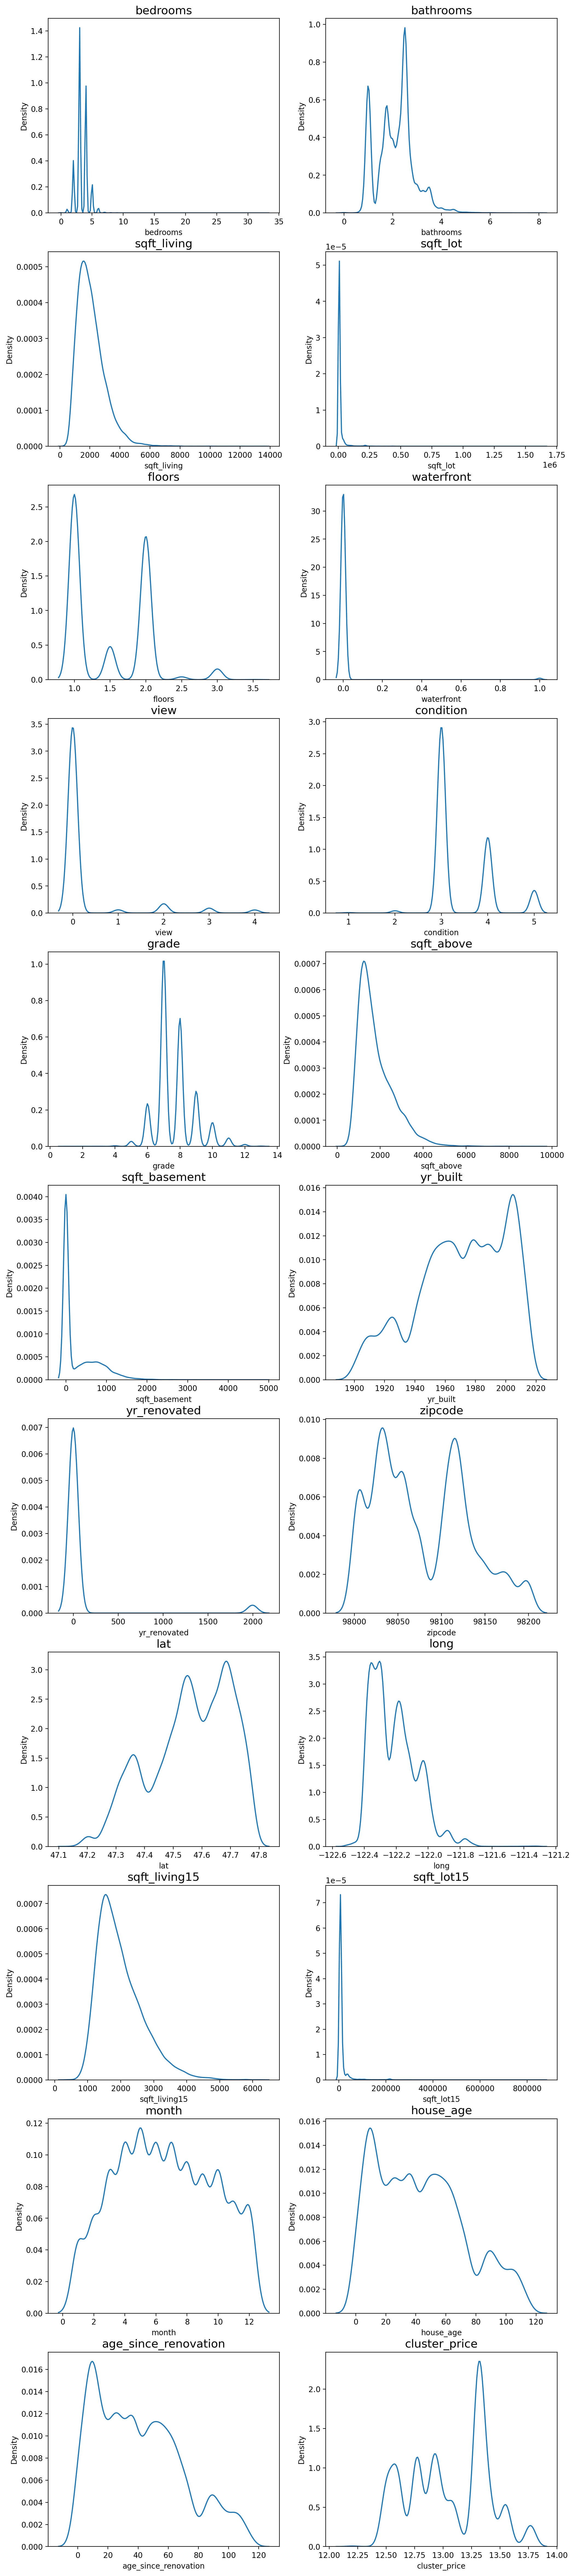

In [171]:
# fig, ax = plt.subplots(10, 2, figsize=(20, 60))
#fig, ax = plt.subplots(9, 2, figsize=(12, 50)) 
fig, ax = plt.subplots(11, 2, figsize=(12, 60)) 

# id 변수는 제외하고 분포를 확인합니다.
count = 1
columns = data.columns
for row in range(11):   # 9->11
    for col in range(2):
        # 피처 추가하면서 추가
        if count >= len(columns): # 전체 피처 개수만큼만 출력
            break
        sns.kdeplot(data=data[columns[count]], ax=ax[row][col])
        ax[row][col].set_title(columns[count], fontsize=15)
        count+=1
        # if count == 19 :
        #     break

price, bedrooms, sqft_living, sqft_lot, sqft_above, sqft_basement 변수가 한쪽으로 치우친 경향을 보였습니다.<br>
log-scaling을 통해 데이터 분포를 정규분포에 가깝게 만들어 보겠습니다.

In [172]:
skew_columns = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_lot15', 'sqft_living15']

for c in skew_columns:
    data[c] = np.log1p(data[c].values)

print('얍💢')

얍💢


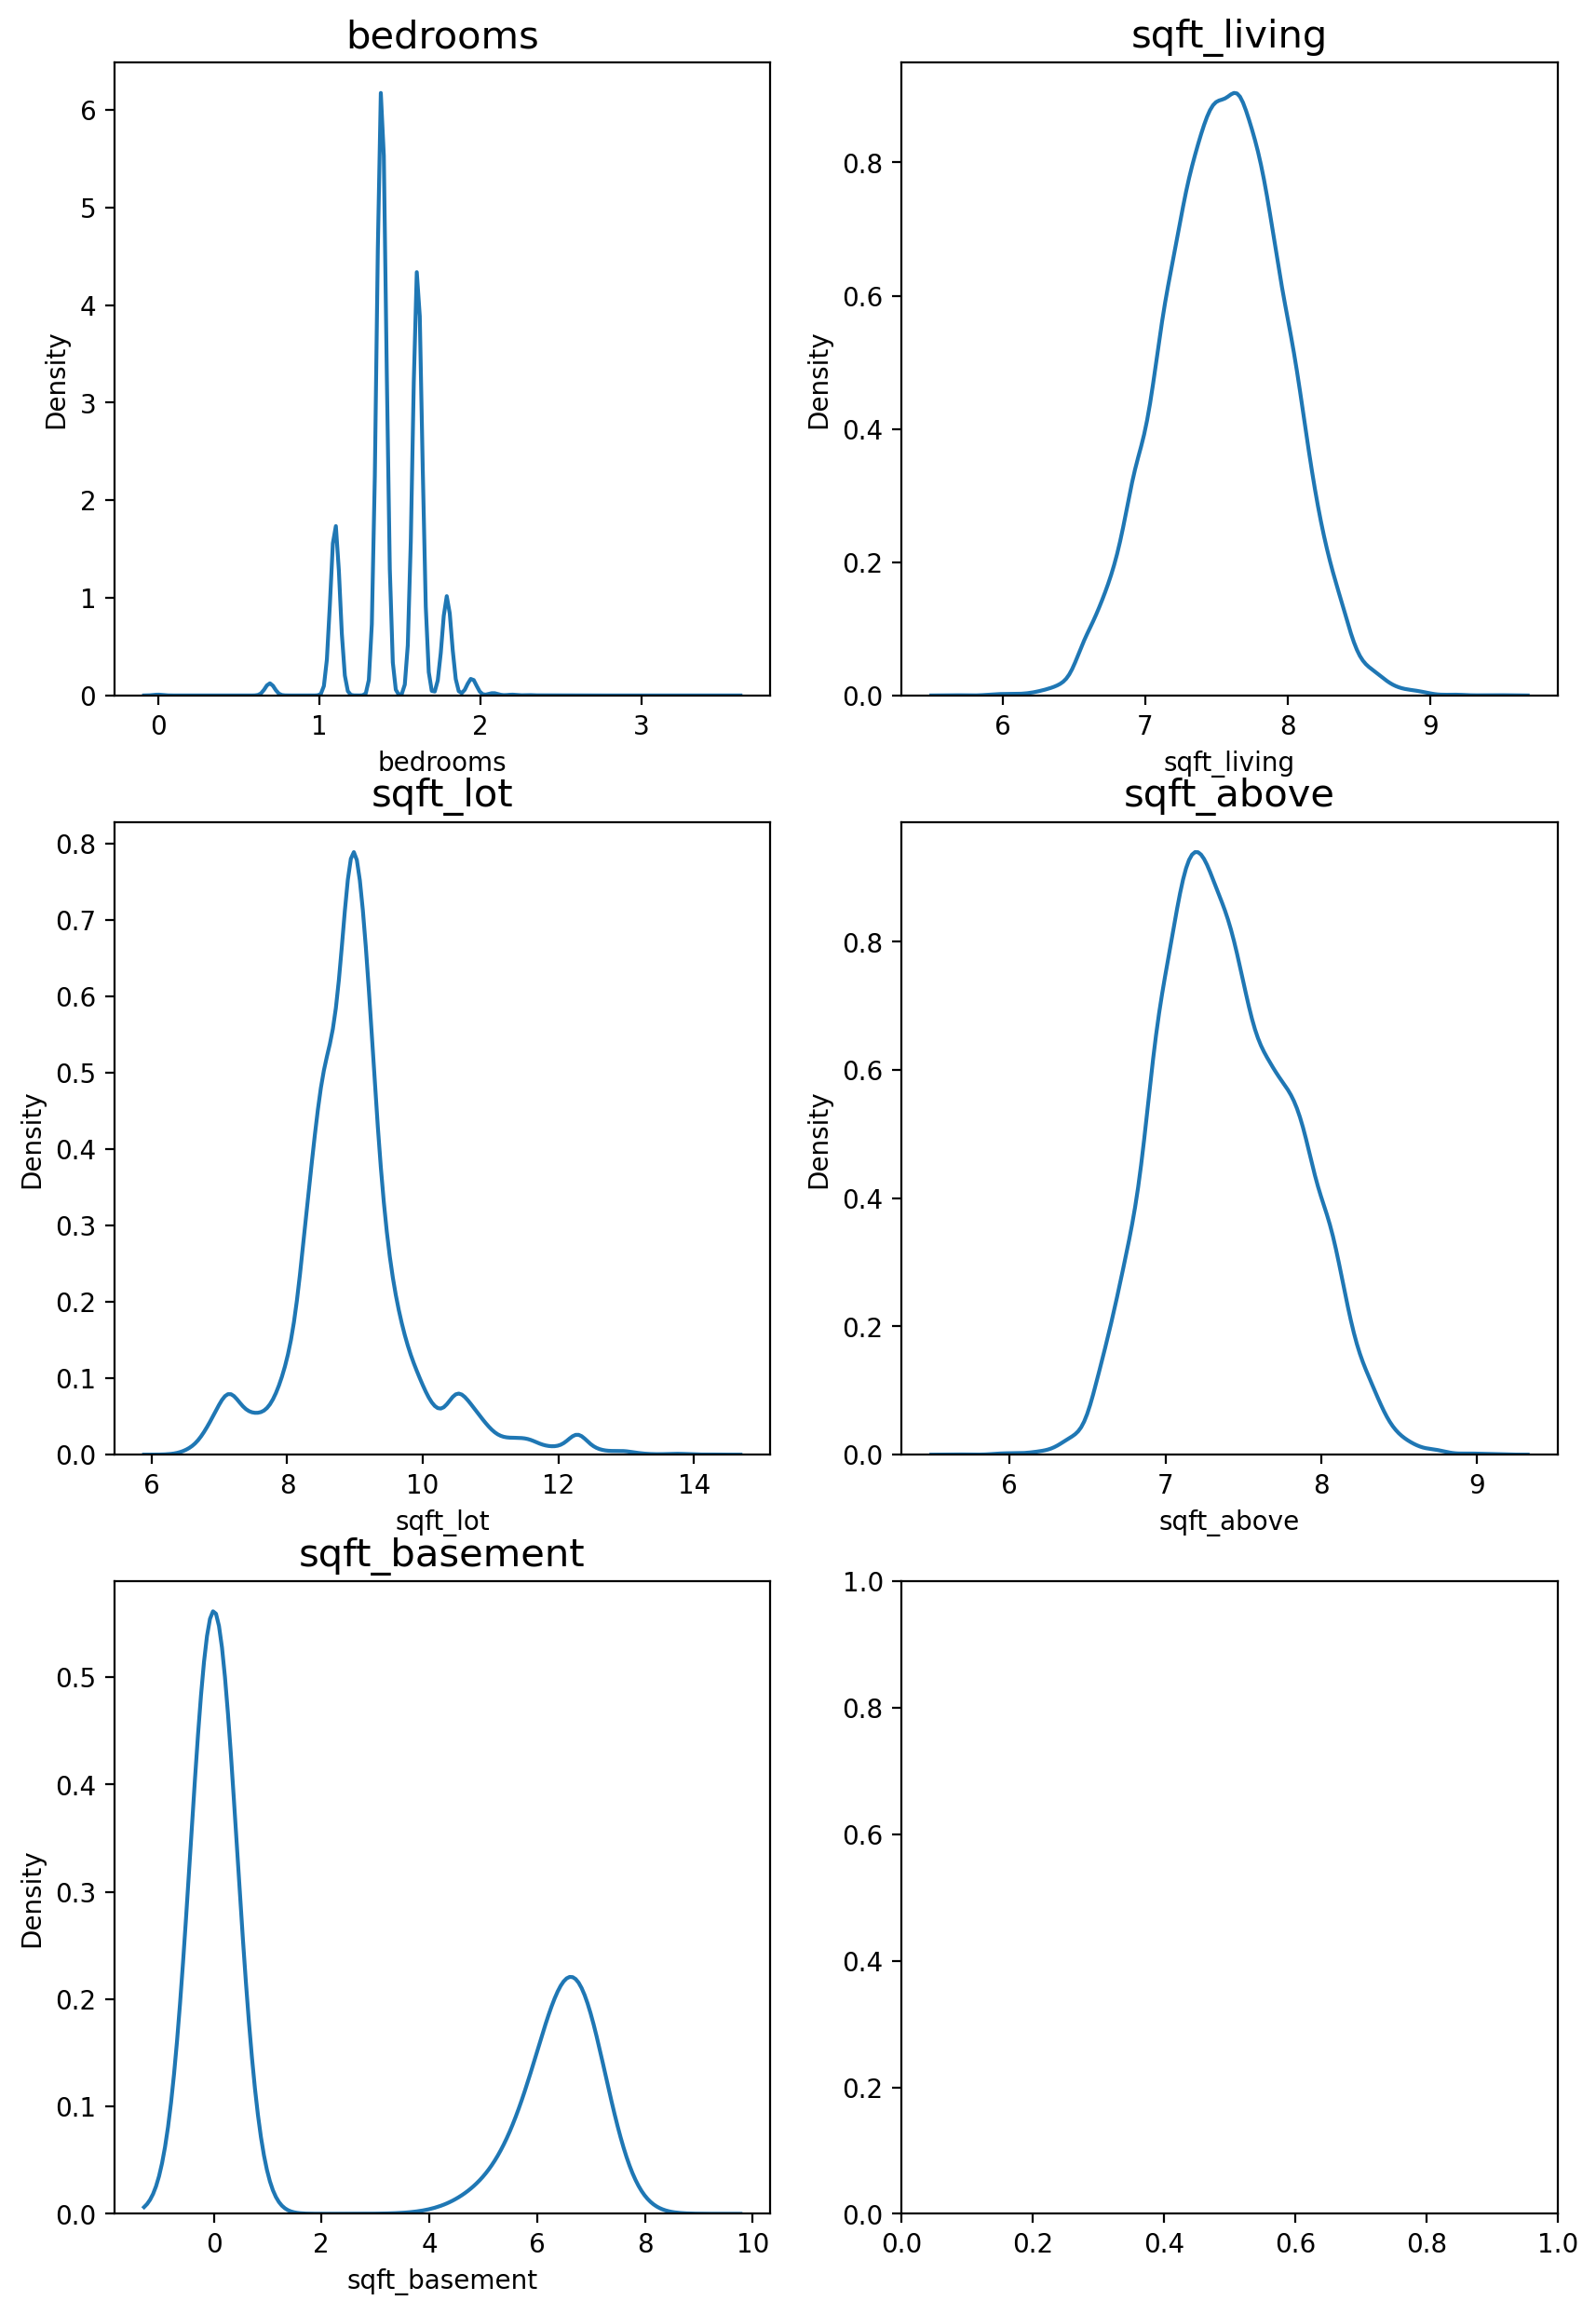

In [173]:
fig, ax = plt.subplots(3, 2, figsize=(10, 15))

count = 0
for row in range(3):
    for col in range(2):
        if count == 5:
            break
        sns.kdeplot(data[skew_columns[count]], ax=ax[row][col])
        ax[row][col].set_title(skew_columns[count], fontsize=15)
        count+=1



어느정도 치우침이 줄어든 분포를 확인할 수 있습니다.

In [174]:

# 훈련/테스트 데이터 분리
sub = data.iloc[train_len:, :]
x = data.iloc[:train_len, :]


## 3. 모델링
### Average Blending
여러가지 모델의 결과를 산술 평균을 통해 Blending 모델을 만들겠습니다.

In [175]:
gboost = GradientBoostingRegressor(
    n_estimators=70,      # (GBoost가 제일 느림)
    learning_rate=0.09,
    max_depth=5,
    subsample=0.8,
    min_samples_leaf=15,
    random_state=2019
)

xgboost = xgb.XGBRegressor(
    n_estimators=600,  # 800->600
    learning_rate=0.05,  # 0.03 -> 0.05
    max_depth=4, 
    subsample=0.7, 
    colsample_bytree=0.7,
    min_child_weight=5, 
    random_state=2019,
    tree_method='hist'  # 이거 추가하면 훨씬 빨라짐
)

lightgbm = lgb.LGBMRegressor(
    n_estimators=1000, 
    learning_rate=0.02,
    num_leaves=63, 
    subsample=0.7, 
    colsample_bytree=0.7,
    min_child_samples=20, 
    random_state=2019, 
    verbose=-1
)

# lightgbm = lgb.LGBMRegressor(
#     n_estimators=800, 
#     learning_rate=0.03,
#     num_leaves=63, 
#     subsample=0.8, 
#     colsample_bytree=0.8,
#     min_child_samples=20, 
#     random_state=2019, 
#     verbose=-1
# )

models = [{'model':gboost, 'name':'GradientBoosting'}, 
          {'model':xgboost, 'name':'XGBoost'},
          {'model':lightgbm, 'name':'LightGBM'}
         ]

print('얍💢')

얍💢


### Cross Validation
교차 검증을 통해 모델의 성능을 간단히 평가하겠습니다.

In [176]:
# def get_cv_score(models):
#     kfold = KFold(n_splits=5, random_state=2019).get_n_splits(x.values)
#     for m in models:
#         print("Model {} CV score : {:.4f}".format(m['name'], np.mean(cross_val_score(m['model'], x.values, y)), 
#                                              kf=kfold))

# def get_cv_score(models):
#     kfold = KFold(n_splits=5).get_n_splits(x.values)
#     for m in models:
#         CV_score = np.mean(cross_val_score(m['model'], X=x.values, y=y, cv=kfold))
#         print(f"Model: {m['name']}, CV score:{CV_score:.4f}")
# print('얍💢')

def get_cv_score(models):
    kfold = KFold(n_splits=5, random_state=2019, shuffle=True).get_n_splits(x.values)
    for m in models:
        # scoring을 neg_mean_squared_error로 설정하여 RMSE 계산
        rmse_scores = np.sqrt(-cross_val_score(m['model'], X=x.values, y=y, 
                                             scoring='neg_mean_squared_error', cv=kfold))
        print(f"Model: {m['name']}, RMSE score: {np.mean(rmse_scores):.4f}")

In [151]:
get_cv_score(models)

Model: GradientBoosting, RMSE score: 0.1681
Model: XGBoost, RMSE score: 0.1599
Model: LightGBM, RMSE score: 0.1600


### Make Submission

회귀 모델의 경우에는 cross_val_score 함수가 R<sup>2</sup>를 반환합니다.<br>
R<sup>2</sup> 값이 1에 가까울수록 모델이 데이터를 잘 표현함을 나타냅니다. 3개 트리 모델이 상당히 훈련 데이터에 대해 괜찮은 성능을 보여주고 있습니다.<br> 훈련 데이터셋으로 3개 모델을 학습시키고, Average Blending을 통해 제출 결과를 만들겠습니다.

In [64]:
def AveragingBlending(models, x, y, sub_x):
    # 1. 각 모델 학습
    for m in models : 
        m['model'].fit(x.values, y)

    # 2. 각 모델의 예측값(로그 단위) 수집
    predictions = np.column_stack([
        m['model'].predict(sub_x.values) for m in models
    ])

    # 3. 로그 단위에서 평균 계산 (추가)
    combined_pred = np.mean(predictions, axis=1)

    # 4. 다시 원래 가격 단위로 복원 (로그벗기기)(expm1)
    return np.expm1(combined_pred)
    
    # return np.mean(predictions, axis=1)

In [36]:
# 가중치 블렌딩
# Weighted:  A×0.4 + B×0.35 + C×0.25 → 성능 좋은 모델에 더 높은 비중
def WeightedBlending(models, x, y, sub_x):
    scores = []
    preds = []
    
    kfold = KFold(n_splits=5, shuffle=True, random_state=2019)

    # 1. 각 모델 CV RMSE 계산
    for m in models:
        rmse = np.mean(np.sqrt(-cross_val_score(
            m['model'], x.values, y,
            scoring='neg_mean_squared_error', cv=kfold
        )))
        scores.append(1 / rmse)
        m['model'].fit(x.values, y)
        preds.append(m['model'].predict(sub_x.values))
        
    # 2. 가중치 정규화 (합이 1이 되도록)
    weights = np.array(scores) / sum(scores)
    print("Weights:", {m['name']: f"{w:.3f}" for m, w in zip(models, weights)})

    # 3. 가중 평균으로 예측값 합산
    combined = np.average(preds, axis=0, weights=weights)

    # 4. log 벗기기
    return np.expm1(combined)


In [177]:
# 스태킹 앙상블(Stacking Ensemble)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

def stacking(models, x, y, sub_x):
    kf = KFold(n_splits=5, shuffle=True, random_state=2019)
    train_meta = np.zeros((x.shape[0], len(models)))
    test_meta = np.zeros((sub_x.shape[0], len(models)))
    
    for i, m in enumerate(models):
        test_preds = np.zeros((sub_x.shape[0], 5))
        for fold, (tr_idx, val_idx) in enumerate(kf.split(x)):
            m['model'].fit(x.values[tr_idx], y.values[tr_idx])
            train_meta[val_idx, i] = m['model'].predict(x.values[val_idx])
            test_preds[:, fold] = m['model'].predict(sub_x.values)
        test_meta[:, i] = test_preds.mean(axis=1)
    
    # 메타 모델
    meta = Ridge(alpha=1.0)
    meta.fit(train_meta, y)

    # === RMSE 출력 ===
    oof_pred = meta.predict(train_meta)
    rmse = np.sqrt(mean_squared_error(y, oof_pred))
    print(f"Stacking OOF RMSE: {rmse:.4f}")
    # ================
    
    final_pred = meta.predict(test_meta)
    return np.expm1(final_pred)

In [178]:
# y_pred = AveragingBlending(models, x, y, sub)
# y_pred = WeightedBlending(models, x, y, sub)
y_pred = stacking(models, x, y, sub)

Stacking OOF RMSE: 0.1567


In [154]:
def get_ordered_importance(models, x, y):
    importance_summary = pd.DataFrame({'Feature': x.columns})
    
    for m in models:
        model = m['model']
        model.fit(x.values, y)
        
        # 모델별 중요도 수치 추가
        importance_summary[m['name']] = model.feature_importances_
        
    # LightGBM 기준으로 내림차순 정렬
    # importance_summary = importance_summary.sort_values(by='LightGBM', ascending=False).reset_index(drop=True)
    
    # 세 모델 중요도 평균으로 정렬
    importance_summary['Average'] = (
        importance_summary['GradientBoosting'] / importance_summary['GradientBoosting'].sum() +
        importance_summary['XGBoost'] / importance_summary['XGBoost'].sum() +
        importance_summary['LightGBM'] / importance_summary['LightGBM'].sum()
    ) / 3

    importance_summary = importance_summary.sort_values(by='Average', ascending=False)
    return importance_summary

# 실행
ordered_df = get_ordered_importance(models, x, y)
print(ordered_df)

                 Feature  GradientBoosting   XGBoost  LightGBM   Average
23         zipcode_price          0.399082  0.294323      1907  0.243951
24        grade_x_living          0.364680  0.241968      2957  0.222088
9                  grade          0.044898  0.098180       837  0.053318
22         cluster_price          0.038369  0.070343       994  0.042917
15                   lat          0.028502  0.029959      3448  0.042659
16                  long          0.027598  0.013303      4274  0.042357
3            sqft_living          0.004829  0.052096      2502  0.035790
25            lat_x_long          0.017074  0.015136      3232  0.032457
4               sqft_lot          0.009385  0.006973      3844  0.031286
17         sqft_living15          0.010324  0.009857      3622  0.031068
7                   view          0.018028  0.053608       644  0.028207
10            sqft_above          0.006501  0.012026      3010  0.026404
18            sqft_lot15          0.002038  0.00386

submission DataFrame 생성

In [179]:
sub = pd.DataFrame(data={'id':sub_id,'price':y_pred})

예측 가격 submission.csv 저장

In [180]:
sub.to_csv('submission.csv', index=False)

## Kaggle submission

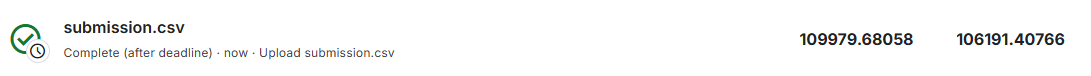